# *K-NN: K-Nearest Neighbors Regressor (KNN Regressor)*

## 1. Carga de Datos

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
import joblib
from pathlib import Path

Configuración para que se cree en la carpeta models en la raiz

In [66]:
carpeta_notebooks = Path.cwd()
raiz_proyecto = carpeta_notebooks.parent
carpeta_models = raiz_proyecto / "models"
carpeta_models.mkdir(parents=True, exist_ok=True)

#print(f"📁 Raíz detectada: {raiz_proyecto}")
#print(f"💾 Carpeta de destino del modelo: {carpeta_models}\n")

Carga del dataset Limpio

In [67]:
csv_path = raiz_proyecto / "data" / "clean" / "players_clean.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {csv_path}")

df = pd.read_csv(csv_path)

print("⚙️ Preparando características y limpieza de nulos...")

⚙️ Preparando características y limpieza de nulos...


## 2. Preparación de los datos

### Asegurandose de que no existen valores Nulos

In [68]:
df['age'] = df['age'].fillna(df['age'].median())
df['height_in_cm'] = df['height_in_cm'].fillna(df['height_in_cm'].median())
df['position'] = df['position'].fillna('Missing').astype(str)
df['market_value_in_eur'] = df['market_value_in_eur'].fillna(0)

### Variables de Entrada y Objetivo (X e Y)

In [69]:
columnas = ['age', 'height_in_cm', 'position']
X = df[columnas]
y = df['market_value_in_eur']

## 3. Pipeline de Prepocesamiento (Conversión a números y escalado)

### Transformador de Columnas (Categóricas y Escalado)

Creamos el preprocesador que tratará cada columna de manera independiente:

* Las numéricas se estandarizan (StandardScaler)

* Las categóricas se convierten a binarias/numéricas (OneHotEncoder)

In [70]:
columnas_numericas = ['age', 'height_in_cm']
columnas_categoricas = ['position']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)
    ]
)

## 4. Configuración de K-FOLD CROSS-VALIDATION

In [71]:
# Usamos 5 bloques (Folds). shuffle=True mezcla aleatoriamente los datos antes de separar
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 5. Validación Cruzada y Entrenamiento del Pipeline K-NN

In [72]:
# Instanciamos el regresor KNN
knn_model = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)

In [73]:
# Unificamos el preprocesamiento y el modelo dentro del Pipeline definitivo
pipeline_knn = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('modelo', knn_model)
])

print("\n🚀 Ejecutando K-Fold Cross-Validation (K=5)...")


🚀 Ejecutando K-Fold Cross-Validation (K=5)...


In [74]:
# Medimos el Coeficiente de Determinación (R²) de forma robusta en los 5 bloques
scores_r2 = cross_val_score(pipeline_knn, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f"   📊 R² por cada iteración (Fold): {scores_r2}")
print(f"   📈 Promedio R² de Validación Cruzada: {np.mean(scores_r2):.4f} (+/- {np.std(scores_r2):.4f})")

   📊 R² por cada iteración (Fold): [-0.14564688 -0.14864553 -0.19103796 -0.04488287 -0.16244499]
   📈 Promedio R² de Validación Cruzada: -0.1385 (+/- 0.0495)


In [75]:
# --- ENTRENAMIENTO FINAL ---
# Ajustamos el Pipeline completo con el 100% de los datos para aprovechar todo el dataset
print(f"\n🧠 Entrenando modelo KNN final con el dataset completo...")
pipeline_knn.fit(X, y)


🧠 Entrenando modelo KNN final con el dataset completo...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['age','height_in_cm','position']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the

In [76]:
# Guardamos el pipeline completo (.pkl) de forma segura en la raíz
filename = carpeta_models / "knn_regressor_model.pkl"
joblib.dump(pipeline_knn, filename)
#print(f"   💾 Guardado de forma absoluta en: '{filename}'\n")

['c:\\Users\\Flor\\Desktop\\Programacion\\DA-Project-Regression-Grupo2\\models\\knn_regressor_model.pkl']

## 6. Demostraciones Gráficas de Rendimiento

In [77]:
print("📊 Generando demostraciones gráficas para el análisis...")

📊 Generando demostraciones gráficas para el análisis...


In [78]:
# Realizamos predicciones globales para evaluar visualmente el comportamiento
y_pred = pipeline_knn.predict(X)
errores = y - y_pred

In [79]:
# Activamos el estilo visual de seaborn
sns.set_theme(style="whitegrid")

### Gráfico 1: Valores Reales vs Predicciones


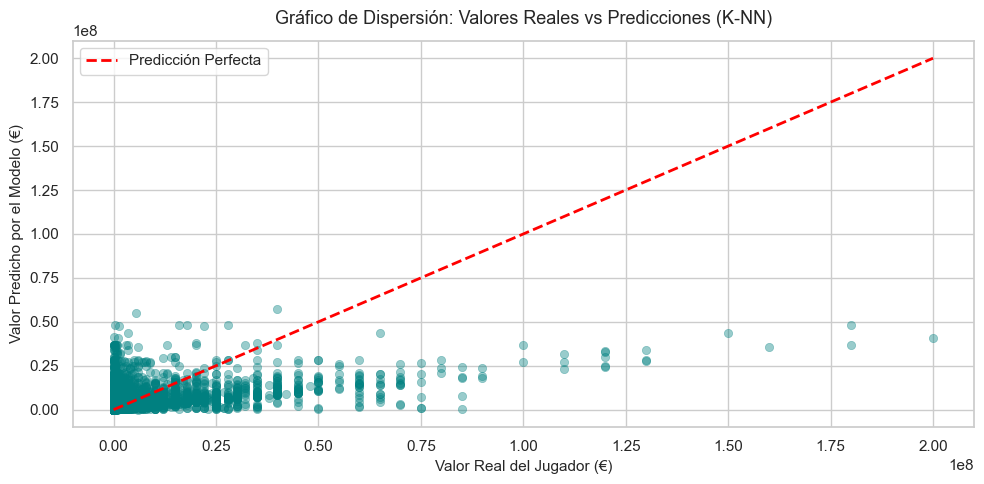

In [80]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y, y=y_pred, alpha=0.4, color='teal', edgecolor=None)

# Línea diagonal ideal (Predicción Perfecta)
max_val = max(max(y), max(y_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

plt.title('Gráfico de Dispersión: Valores Reales vs Predicciones (K-NN)', fontsize=13, pad=12)
plt.xlabel('Valor Real del Jugador (€)', fontsize=11)
plt.ylabel('Valor Predicho por el Modelo (€)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

### Gráfico 2: Distribución de Errores (Residuos)

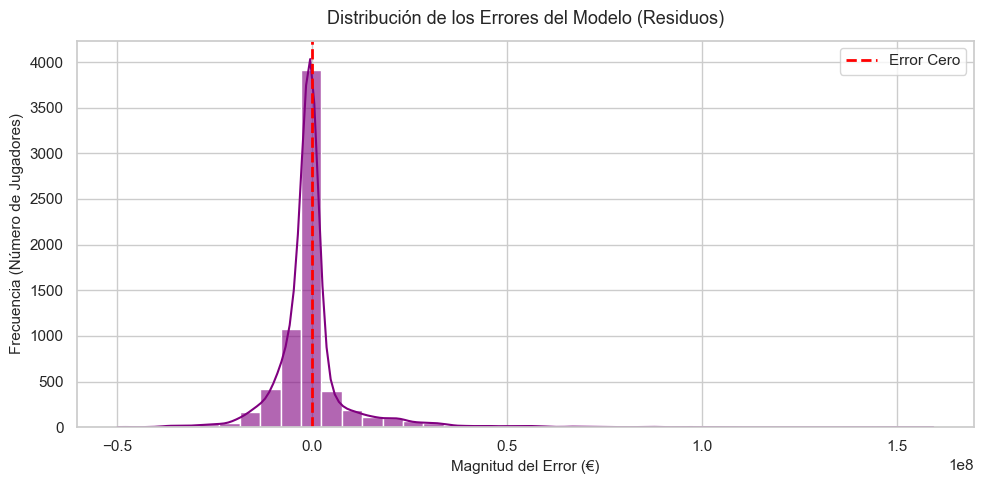

In [81]:
plt.figure(figsize=(10, 5))
sns.histplot(errores, kde=True, color='purple', bins=40, alpha=0.6)

# Línea vertical de referencia en el error cero
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')

plt.title('Distribución de los Errores del Modelo (Residuos)', fontsize=13, pad=12)
plt.xlabel('Magnitud del Error (€)', fontsize=11)
plt.ylabel('Frecuencia (Número de Jugadores)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
print("✨ ¡Proceso completado! Modelo guardado y gráficos generados con éxito.")

✨ ¡Proceso completado! Modelo guardado y gráficos generados con éxito.
